# Cell Cycle Map Workflow

This tutorial builds a cell cycle map from single-cell imaging features:

1. Download a public dataset and convert it to an `AnnData` object
2. Select informative features with a random forest (`cc_mapping.core`)
3. Search PHATE hyperparameters and embed the cells (`cc_mapping.manifold`)
4. Visualize the map (`cc_mapping.manifold`, `cc_mapping.plot`)

The PHATE steps need the optional `phate` dependency:

```bash
pip install "cc-mapping[manifold]"
```

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st

from cc_mapping import manifold, plot, preprocess
from cc_mapping.feature_selection import RFMinMaxSelector, RFTopNSelector

%matplotlib inline

## Download the data

The dataset is `control_manifold_allfeatures.csv` from [Zenodo record 4525425](https://zenodo.org/records/4525425) (~40 MB). It is downloaded once into `./data`; figures are saved to `./figs`.

In [2]:
url = "https://zenodo.org/records/4525425/files/control_manifold_allfeatures.csv?download=1"

cwd = Path.cwd()
download_path = cwd / "data" / "control_manifold_allfeatures.csv"
fig_dir = cwd / "figs"

download_path.parent.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)

if not download_path.exists():
    urlretrieve(url, download_path)

## Load the data and build an AnnData object

In [3]:
csv = pd.read_csv(download_path, index_col=0, low_memory=False)
csv.index = csv.index.astype(str)

# Drop the published annotations and PHATE coordinates -- this workflow recomputes them
csv = csv.drop(columns=["annotated age", "annotated phase"])
csv = csv.drop(columns=csv.filter(regex="PHATE").columns)

# Optional: remove parentheses and spaces from the column names
csv.columns = csv.columns.str.replace(r"[()]", "", regex=True).str.replace(" ", "_")
csv.head()

,E2F1_nuc_median,cycA_nuc_median,cycD1_nuc_median,p21_nuc_median,Int_Intg_DNA_nuc,Skp2_nuc_median,Cdt1_nuc_median,Nuc_area,Cdh1_nuc_median,cycE_nuc_median,...,RSK1_phospho/total_PN,cycD1_over_p21,cyto_over_DNA,CDK2_cyto_over_nuc,STAT3_phospho/total_nuc,age,phase,PCNA_foci,DNA_content,Local_cell_density
Unnamed: 0.1.1,,,,,,,,,,,,,,,,,,,,,
0,0.006851,0.005875,0.019471,0.026032,5.746899,0.006493,0.005158,553.0,0.014336,0.009262,...,1.160714,0.747948,909.012025,3.974065,1.770186,10.263173,G1,0.005151,2.298759,7.0
1,0.012360,0.028153,0.007462,0.004318,8.852262,0.022797,0.005951,490.0,0.015229,0.008392,...,1.267760,1.727915,654.860857,4.824163,1.455814,12.109644,S,0.006861,3.540905,1.0
2,0.007279,0.005707,0.006592,0.003632,4.951003,0.015366,0.004929,363.0,0.005730,0.009117,...,1.029940,1.815126,537.062859,4.273837,1.290323,4.954907,G1,0.004148,1.980401,6.0
3,0.006531,0.016602,0.009369,0.006264,10.466743,0.019196,0.005234,579.0,0.009361,0.007118,...,1.096774,1.495737,361.621566,3.177175,1.435065,13.424587,G2,0.002457,4.186697,9.0
5,0.006744,0.006027,0.009033,0.005295,5.249119,0.010422,0.007797,296.0,0.008896,0.007767,...,1.088757,1.706052,532.660833,6.257769,1.266304,1.828240,G1,0.003277,2.099648,3.0


In [4]:
# String columns become per-cell annotations (adata.obs); numeric columns become features (adata.X)
obs = csv.select_dtypes(include="object")
features = csv.select_dtypes(exclude="object")

adata = ad.AnnData(X=features.values, obs=obs, var=pd.DataFrame(index=features.columns))
adata

AnnData object with n_obs × n_vars = 6797 × 294
    obs: 'phase'

## Keep the proliferating cells and set the phase colors

Keep the G1, S and G2 cells, then store `phase` as a categorical with one color per category in `adata.uns["phase_colors"]` (the scanpy convention). Every `cc_mapping` plot that colors by `"phase"` uses those colors; without them a default palette is used. A column of literal color strings (for example `adata.obs["phase_colors"] = ["orange", ...]`) works too.

In [5]:
adata = preprocess.row_data_partitioning(adata, search_str=["G1", "S", "G2"], search_obs="phase")

adata.obs["phase"] = pd.Categorical(adata.obs["phase"], categories=["G1", "S", "G2"])
adata.uns["phase_colors"] = ["orange", "orchid", "dodgerblue"]

adata.obs["phase"].value_counts()

phase
G1    3803
S     2005
G2     940
Name: count, dtype: int64

## Feature selection with a random forest

`RFMinMaxSelector` and `RFTopNSelector` from `cc_mapping.feature_selection` train a random forest to predict `phase` and rank the features by importance; `transform_adata` stores the selected features as a boolean column in `adata.var`:

- `RFMinMaxSelector` adds features in order of importance until the accuracy stops improving by more than `threshold` for `stable_iterations` iterations. `plot_accuracy_curve` plots the accuracy against the number of features.
- `RFTopNSelector(n_features=N)` keeps the top `N` features.

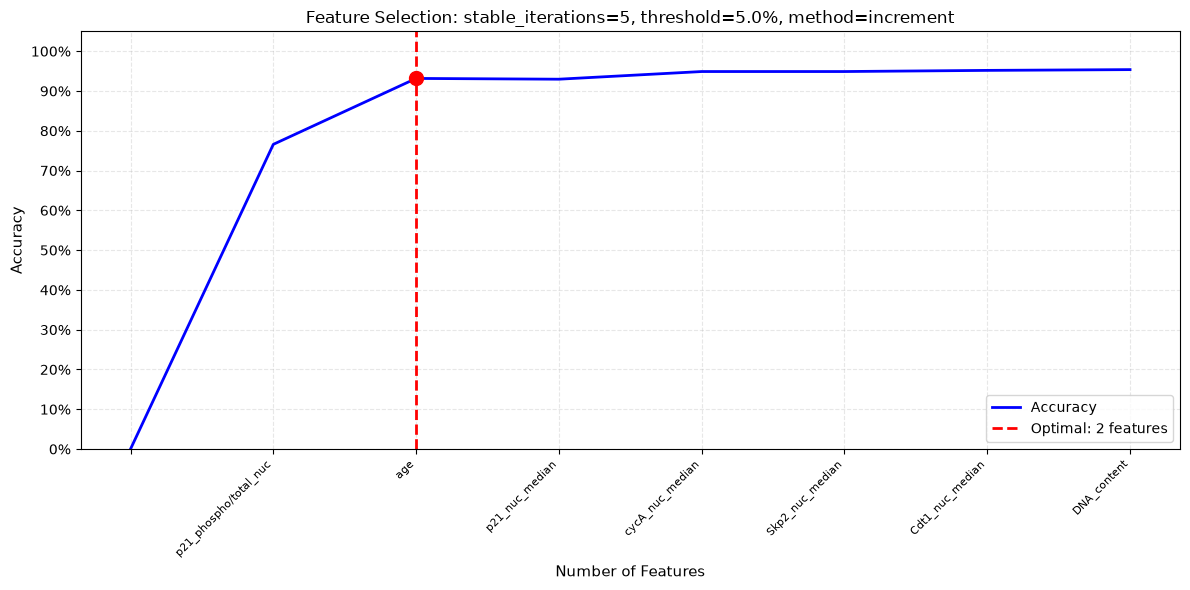

['p21_phospho/total_nuc', 'age']

In [6]:
rf_threshold = 0.05
feature_set_name = f"RMM_PROL_{rf_threshold}"

selector = RFMinMaxSelector(
    threshold=rf_threshold,
    stable_iterations=5,
    verbose=False,  # True (the default) also prints classification reports and a progress bar
)
selector.fit_adata(adata, adata.var_names, "phase")
selector.transform_adata(adata, var_key=feature_set_name)
fig = selector.plot_accuracy_curve()

list(adata.var_names[adata.var[feature_set_name]])

In [7]:
num_features = 4

selector = RFTopNSelector(n_features=num_features, verbose=False)
selector.fit_adata(adata, adata.var_names, "phase")
selector.transform_adata(adata, var_key=f"RM_{num_features}_fs")

list(adata.var_names[adata.var[f"RM_{num_features}_fs"]])

['cycA_nuc_median', 'p21_nuc_median', 'p21_phospho/total_nuc', 'age']

Any boolean column in `adata.var` can be used as a feature set, so you can also define one by hand:

In [8]:
adata.var["all_features"] = True

## PHATE hyperparameter search

PHATE runs on a z-scored layer restricted to the selected features. `perform_phate_hyperparameter_search` builds one grid per value of the constant parameter, with the other two parameters as rows and columns. `final_grid_dims` combines the grids into a single figure, which is saved to `save_path`.

In [9]:
adata.layers["z-score"] = st.zscore(adata.X, axis=0)

Generating hyperparameter search plots:   0%|          | 0/2 [00:00<?, ?it/s]

.../site-packages/graphtools/graphs.py:803: RuntimeWarning: Detected zero distance between samples 88 and 4818, 1340 and 2324. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


.../site-packages/graphtools/graphs.py:803: RuntimeWarning: Detected zero distance between samples 88 and 4818, 1340 and 2324. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -1.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.


.../site-packages/graphtools/graphs.py:803: RuntimeWarning: Detected zero distance between samples 88 and 4818, 1340 and 2324. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


...

    SGD-MDS may not have converged: stress changed by -1.4% in final iterations. Consider increasing n_iter or adjusting learning_rate.


.../site-packages/graphtools/graphs.py:803: RuntimeWarning: Detected zero distance between samples 88 and 4818, 1340 and 2324. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -1.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.


Generating hyperparameter search plots: 100%|██████████| 2/2 [02:26<00:00, 76.71s/it]

Generating hyperparameter search plots: 100%|██████████| 2/2 [02:26<00:00, 73.16s/it]

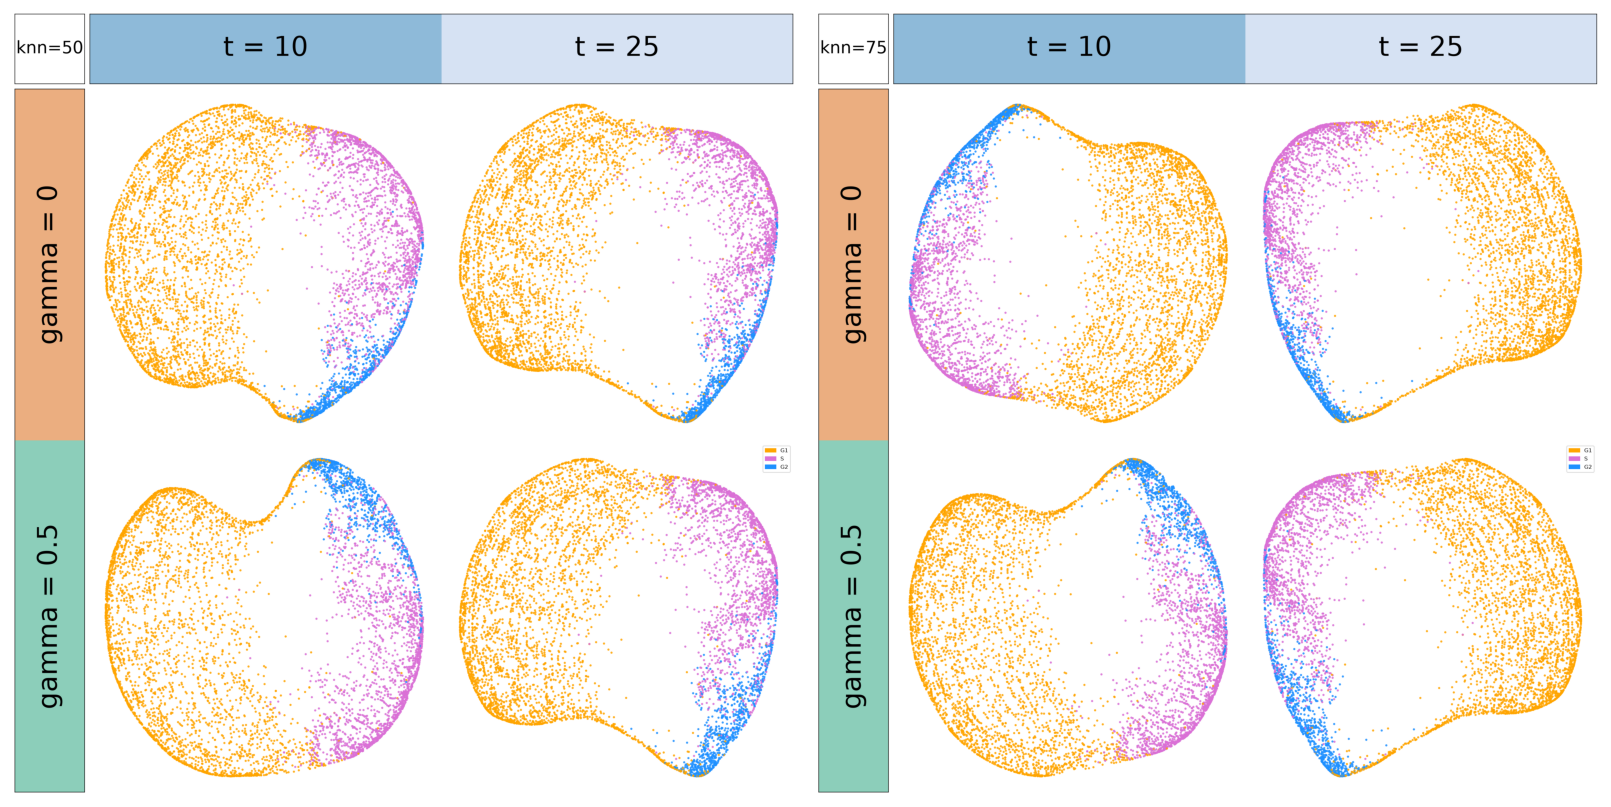

In [10]:
base_config = manifold.PHATEConfig(n_components=2, n_jobs=-1, random_state=0)

hyperparam_grid = manifold.PHATEHyperparamGrid(
    row_param_name="gamma",
    col_param_name="t",
    constant_param_name="knn",
    row_param_values=[0, 0.5],
    col_param_values=[10, 25],
    constant_param_values=[50, 75],
)

figures = manifold.perform_phate_hyperparameter_search(
    adata=adata,
    feature_set=feature_set_name,
    layer="z-score",
    hyperparam_grid=hyperparam_grid,
    base_config=base_config,
    color_name="phase",
    final_grid_dims=(1, 2),
    unit_size=8,
    plot_kwargs={"s": 5, "alpha": 0.8, "rasterized": True},
    save_path=str(fig_dir / "cell_cycle_hyperparameter_search.png"),
    show_legend=True,
)
figures[0]

## Run PHATE with the chosen parameters

In [11]:
optimal_config = manifold.PHATEConfig(
    n_components=2, t=10, gamma=0, knn=75, n_jobs=-1, random_state=0
)

adata = manifold.run_phate(
    adata=adata,
    feature_set=feature_set_name,
    layer="z-score",
    phate_config=optimal_config,
    obsm_save_key="X_phate",
)
adata

.../site-packages/graphtools/graphs.py:803: RuntimeWarning: Detected zero distance between samples 88 and 4818, 1340 and 2324. Consider removing duplicates to avoid errors in downstream processing.
  warnings.warn(


    SGD-MDS may not have converged: stress changed by -1.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.


AnnData object with n_obs × n_vars = 6748 × 294
    obs: 'phase'
    var: 'RMM_PROL_0.05', 'RM_4_fs', 'all_features'
    uns: 'phase_colors'
    obsm: 'X_phate'
    layers: 'z-score'

## Plot the cell cycle map

`PHATEVisualizer.plot_from_adata` colors the map by any `adata.obs` column or feature name. Categorical columns get one color per category, numeric values are colormapped. `plot.get_legend` returns legend patches that match the plotted colors.

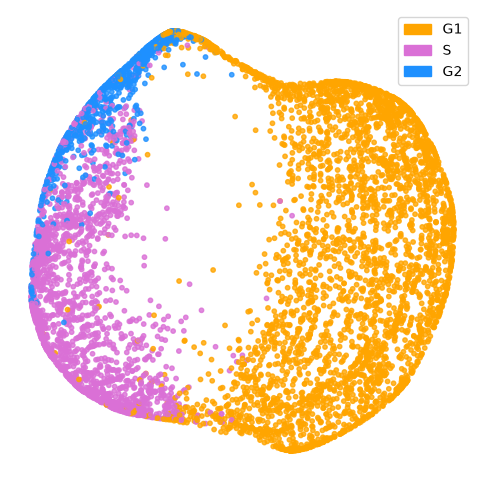

In [12]:
kwargs = {"s": 10, "alpha": 0.8, "rasterized": True}

fig, ax = manifold.PHATEVisualizer.plot_from_adata(
    adata, color_name="phase", unit_size=6, kwargs=kwargs, return_fig=True
)
patches, _ = plot.get_legend(adata, "phase")
ax.legend(handles=patches, loc="upper right")
plt.show()

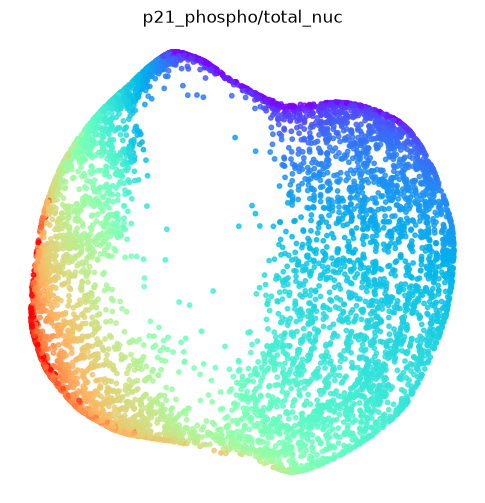

In [13]:
fig, ax = manifold.PHATEVisualizer.plot_from_adata(
    adata, color_name="p21_phospho/total_nuc", unit_size=6, kwargs=kwargs, return_fig=True
)
ax.set_title("p21_phospho/total_nuc")
plt.show()

`plot.plot_row_partitions` draws one row per color and one column per group in `obs_search_term`, plus an `ALL` column with every cell. The full map is drawn in grey behind each panel.

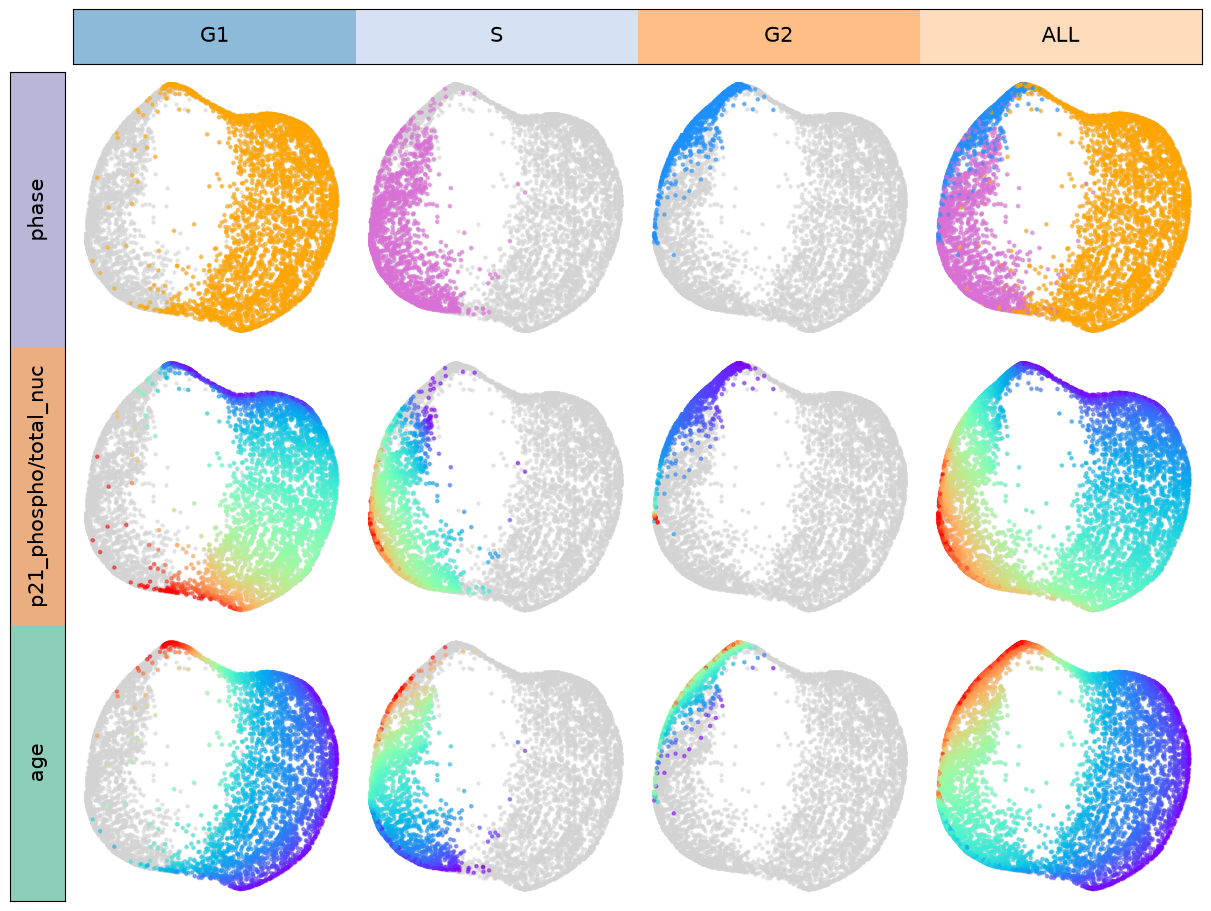

In [14]:
fig = plot.plot_row_partitions(
    adata,
    obs_search_term="phase",
    colors=["phase", "p21_phospho/total_nuc", "age"],
    column_labels=["G1", "S", "G2", "ALL"],
    unit_size=3,
    kwargs={"s": 5, "alpha": 0.5, "rasterized": True},
)
plt.show()